In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/solve_log.csv",sep = ',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1158 entries, 0 to 1157
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   1158 non-null   object
 1   target     1158 non-null   object
 2   score      1158 non-null   int64 
 3   solvetree  1158 non-null   object
dtypes: int64(1), object(3)
memory usage: 36.3+ KB


In [3]:
df['score'].mean()

np.float64(3.033678756476684)

In [4]:
df_without_failed = df[df['target'] != 'FAILED']
df_without_failed['target_len'] = df_without_failed['target'].str.len()

mean_scores = df_without_failed.groupby('target_len')['score'].mean()

/tmp/ipykernel_175097/4180935771.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_without_failed['target_len'] = df_without_failed['target'].str.len()


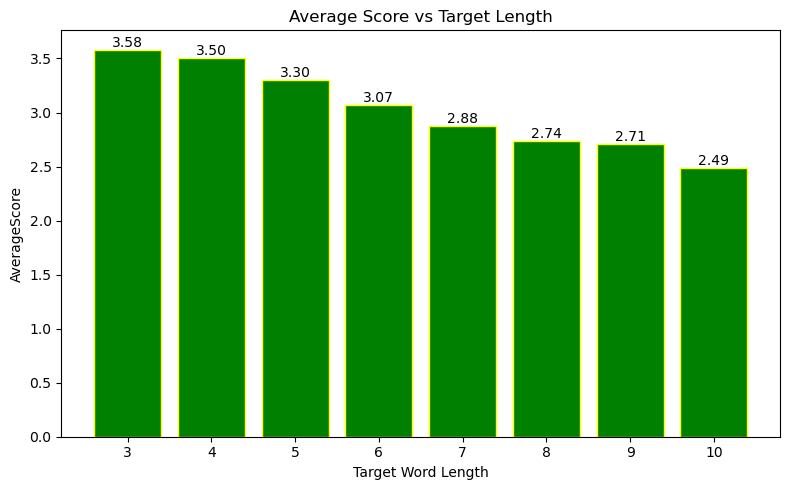

In [5]:
plt.figure(figsize=(8,5))

bars  = plt.bar(mean_scores.index, mean_scores.values, color='green', edgecolor='yellow')

plt.xlabel("Target Word Length")
plt.ylabel("AverageScore")
plt.title("Average Score vs Target Length")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.2f}",
             ha='center',
             va='bottom',
             fontsize=10)

plt.xticks(mean_scores.index)
plt.tight_layout()

plt.savefig("../figures/target_length_vs_average_score.png", dpi=300, bbox_inches="tight")

plt.show()